# More detailed structural analysis of intra-basin variability (tICA dihedrals)

In [101]:
%load_ext autoreload
%autoreload 2 

data_folder = "../data/"

import numpy as np
import pandas as pd

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "axes.linewidth": 0.9,
    "xtick.major.width": 0.9,
    "ytick.major.width": 0.9,
    "xtick.minor.width": 0.7,
    "ytick.minor.width": 0.7,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import LogLocator
import plotting_utils as pu
from matplotlib.patches import Patch
from matplotlib import color_sequences
from matplotlib.colors import TwoSlopeNorm

#import networkx as nx # graph visualization of MSM microstates and macrostates model

from deeptime.markov import TransitionCountEstimator
from deeptime.markov.msm import MaximumLikelihoodMSM

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Prepare data

In [102]:
trajectories_labels = ["tica_distances"]



total_time_micros = 305
time_step_micros =  total_time_micros / 1526041 #/ distances.shape[0]
time_step_nanos = time_step_micros * 10**3
print("Time step (microseconds)", time_step_micros) # 2x10^-4 microseconds
print("Time step (nanoseconds)", time_step_micros * 10**3) # 0.2 nanoseconds
print("Time step (picoseconds)", time_step_micros * 10**6) # 200 picoseconds
one_microsecond_in_frames = int(1 / time_step_micros)
print("One microsecond in frames", one_microsecond_in_frames) # 5000 frames


# --------------------------------
# RMSD from crystal distances
# --------------------------------
crystal_dist = np.loadtxt(
    data_folder + "hp35.crystaldists",
    delimiter=" ",
    dtype=float
)

print("Crystal distances shape", crystal_dist.shape) 
rmsd = np.sqrt(np.mean(crystal_dist**2, axis=1))  # [nm]

Time step (microseconds) 0.00019986356854108112
Time step (nanoseconds) 0.19986356854108112
Time step (picoseconds) 199.86356854108112
One microsecond in frames 5003
Crystal distances shape (1526041, 53)


In [103]:

# --------------------------------
# Helix dict
# --------------------------------
helices = {
    "H1": (2, 10),
    "H2": (15, 19),
    "H3": (23, 32),
}

contact_names = np.loadtxt(
    data_folder + "hp35.crystaldists.ndx",
    delimiter=" ",
    dtype=int
)

print("Contact names shape:", contact_names.shape)

# Make sure contact_names is shaped as (n_contacts, 2)
if contact_names.ndim == 1:
    contact_names = contact_names.reshape(-1, 2)

contact_lookup = {i: tuple(contact_names[i]) for i in range(contact_names.shape[0])}

print("First contacts:")
for i in range(min(10, len(contact_lookup))):
    print(i, contact_lookup[i])


# --------------------------------
# Find contacts internal to helices
# --------------------------------

def find_contacts_within_region(contact_names, start, end):
    """
    Return indices of contacts whose two residues both lie in [start, end].

    Assumes contact_names has shape (n_contacts, 2), with residue numbering
    consistent with the helix definitions.
    """
    indices = []

    for k, (res_i, res_j) in enumerate(contact_names):
        if start <= res_i <= end and start <= res_j <= end:
            indices.append(k)

    return np.array(indices, dtype=int)


helix_contact_indices = {}

for helix_name, (start, end) in helices.items():
    idx = find_contacts_within_region(contact_names, start, end)
    helix_contact_indices[helix_name] = idx

    print(f"\n{helix_name}: residues {start}-{end}")
    print(f"Number of internal contacts: {len(idx)}")

    for k in idx:
        print(f"  column {k}: contact {tuple(contact_names[k])}")

Contact names shape: (53, 2)
First contacts:
0 (1, 5)
1 (1, 6)
2 (1, 9)
3 (1, 10)
4 (1, 14)
5 (1, 34)
6 (2, 6)
7 (3, 7)
8 (3, 14)
9 (4, 8)

H1: residues 2-10
Number of internal contacts: 5
  column 6: contact (2, 6)
  column 7: contact (3, 7)
  column 9: contact (4, 8)
  column 10: contact (5, 9)
  column 11: contact (6, 10)

H2: residues 15-19
Number of internal contacts: 1
  column 33: contact (15, 19)

H3: residues 23-32
Number of internal contacts: 6
  column 44: contact (23, 27)
  column 45: contact (24, 28)
  column 46: contact (25, 29)
  column 47: contact (26, 30)
  column 48: contact (27, 31)
  column 49: contact (28, 32)


In [104]:
# --------------------------------
# Soft contact-based helicity score
# --------------------------------

# If the first row is NOT a native/reference structure, replace this
# with a separately loaded native/reference distance vector.
native_dist = np.zeros_like(crystal_dist[0]) + 0.45 # [nm]

def soft_contact_score(distances, reference_distances, n=6, scale=1.2):
    d0 = scale * reference_distances

    # avoid division by zero in pathological cases
    d0 = np.where(d0 == 0, np.nan, d0)

    return 1.0 / (1.0 + (distances / d0[None, :]) ** n)


soft_contacts = soft_contact_score(
    crystal_dist,
    native_dist,
    n=6,
    scale=1.2
)

helicity_timeseries = {}

for helix_name, idx in helix_contact_indices.items():
    if len(idx) == 0:
        print(f"Warning: no contacts found for {helix_name}")
        helicity_timeseries[helix_name] = np.full(crystal_dist.shape[0], np.nan)
    else:
        helicity_timeseries[helix_name] = np.nanmean(
            soft_contacts[:, idx],
            axis=1
        )

helicity_timeseries["Htot"] = np.nanmean(
    np.vstack([
        helicity_timeseries["H1"],
        helicity_timeseries["H2"],
        helicity_timeseries["H3"],
    ]),
    axis=0
)

In [105]:
MSM_LAG_NS = 200
MSM_LAG_FRAMES = int(MSM_LAG_NS / time_step_nanos) # 200 ns
print("MSM lag time in frames:", MSM_LAG_FRAMES)
N_CLUSTERS = 30
tce = TransitionCountEstimator(lagtime=MSM_LAG_FRAMES, count_mode="sliding-effective")



msm_dict = {}
micro_trajectory_dict = {} # traj -> micro traj
dtrajs_dict = {} # traj -> micro traj


name = trajectories_labels[0]

data = np.load(f"../intermediate_outputs/kmeans_plusplus/{N_CLUSTERS}clusters_{name}.npz")
dtraj = data["traj"].copy()
centers = data["centers"].copy()
C = tce.fit(dtraj).fetch_model()
submodel = C.submodel_largest(directed=True)
print(f"Submodel for {name} has {submodel.n_states} microstates.")
micro_trajectory_dict[name] = submodel.transform_discrete_trajectories_to_submodel(data["traj"])
np.save(f"../intermediate_outputs/microstate_trajs/{N_CLUSTERS}clusters_{MSM_LAG_NS}lag_{name}_submodel.npy", micro_trajectory_dict[name])

dtrajs_dict[name] = pu.clean_assignments(micro_trajectory_dict[name], max_dist= 10000)
if np.any(dtrajs_dict[name] == -1):
    print(f"Warning: {name} has unassigned microstates after cleaning.")
msm = MaximumLikelihoodMSM(reversible = True).fit(submodel).fetch_model()
msm_dict[name] = msm

MSM lag time in frames: 1000
Submodel for tica_distances has 30 microstates.


In [106]:
n_common = 3

pcca_dict = {}
pcca_memberships_dict = {}
macro_assignments_micro_dict = {}

for name in trajectories_labels:
    msm = msm_dict[name]

    pcca = msm.pcca(n_common)
    pcca_dict[name] = pcca

    # shape: n_microstates x 3
    memberships = pcca.memberships
    pcca_memberships_dict[name] = memberships

    # hard assignment of each microstate
    macro_assignments_micro = memberships.argmax(axis=1)
    macro_assignments_micro_dict[name] = macro_assignments_micro

In [107]:
pcca_probabilities_timeseries_dict = {}
hard_assignments_timeseries_dict = {}

for name in trajectories_labels:
    dtraj = dtrajs_dict[name]
    memberships = pcca_memberships_dict[name]

    # shape: n_frames x n_macrostates
    p_macro = memberships[dtraj, :]

    # hard macrostate assignment
    hard = np.argmax(p_macro, axis=1)

    pcca_probabilities_timeseries_dict[name] = p_macro
    hard_assignments_timeseries_dict[name] = hard

    print(name)
    print("p_macro shape:", p_macro.shape)
    print("hard shape:", hard.shape)
    print("macrostate counts:", np.bincount(hard))
    print()

tica_distances
p_macro shape: (1526041, 3)
hard shape: (1526041,)
macrostate counts: [  15883  475514 1034644]



In [108]:


helicity_rows = []

for name in trajectories_labels:
    hard = hard_assignments_timeseries_dict[name]
    n_macrostates = pcca_memberships_dict[name].shape[1]

    observables = {
        "H1": helicity_timeseries["H1"],
        #"H2": helicity_timeseries["H2"],
        "H3": helicity_timeseries["H3"],
        "Htot": helicity_timeseries["Htot"],
    }

    for macro in range(n_macrostates):
        mask = hard == macro

        for obs_name, obs in observables.items():
            values = obs[mask]

            helicity_rows.append({
                "model": name,
                "macrostate": macro,
                "observable": obs_name,
                "n_frames": np.sum(mask),
                "fraction_frames": np.mean(mask),
                "mean": np.nanmean(values),
                "std": np.nanstd(values),
                "median": np.nanmedian(values),
                "q25": np.nanpercentile(values, 25),
                "q75": np.nanpercentile(values, 75),
                "iqr": np.nanpercentile(values, 75) - np.nanpercentile(values, 25),
            })

helicity_macrostate_df = pd.DataFrame(helicity_rows)
helicity_macrostate_df

,model,macrostate,observable,n_frames,fraction_frames,mean,std,median,q25,q75,iqr
0,tica_distances,0,H1,15883,0.010408,0.297983,0.149629,0.283355,0.239042,0.329774,0.090732
1,tica_distances,0,H3,15883,0.010408,0.834955,0.157392,0.917040,0.722082,0.961048,0.238966
2,tica_distances,0,Htot,15883,0.010408,0.541951,0.094718,0.546753,0.478140,0.607834,0.129694
3,tica_distances,1,H1,475514,0.311600,0.483053,0.250704,0.466986,0.298354,0.671483,0.373129
4,tica_distances,1,H3,475514,0.311600,0.643917,0.290986,0.701743,0.376945,0.944398,0.567453
5,tica_distances,1,Htot,475514,0.311600,0.520704,0.179822,0.523368,0.390814,0.657975,0.267161
6,tica_distances,2,H1,1034644,0.677992,0.770554,0.127884,0.784720,0.717029,0.839001,0.121971
7,tica_distances,2,H3,1034644,0.677992,0.935828,0.087322,0.961781,0.949508,0.968252,0.018744
8,tica_distances,2,Htot,1034644,0.677992,0.861175,0.066012,0.875314,0.826526,0.903455,0.076929


In [109]:
helicity_summary_table = helicity_macrostate_df.pivot_table(
    index=["model", "macrostate"],
    columns="observable",
    values="mean"
)

helicity_summary_table


observable                       H1        H3      Htot
model          macrostate                              
tica_distances 0           0.297983  0.834955  0.541951
               1           0.483053  0.643917  0.520704
               2           0.770554  0.935828  0.861175

/var/folders/vk/kftm8379123bsmwrdp8l0xr00000gn/T/ipykernel_3017/1841539344.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[macro].boxplot(
/var/folders/vk/kftm8379123bsmwrdp8l0xr00000gn/T/ipykernel_3017/1841539344.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[macro].boxplot(
/var/folders/vk/kftm8379123bsmwrdp8l0xr00000gn/T/ipykernel_3017/1841539344.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[macro].boxplot(


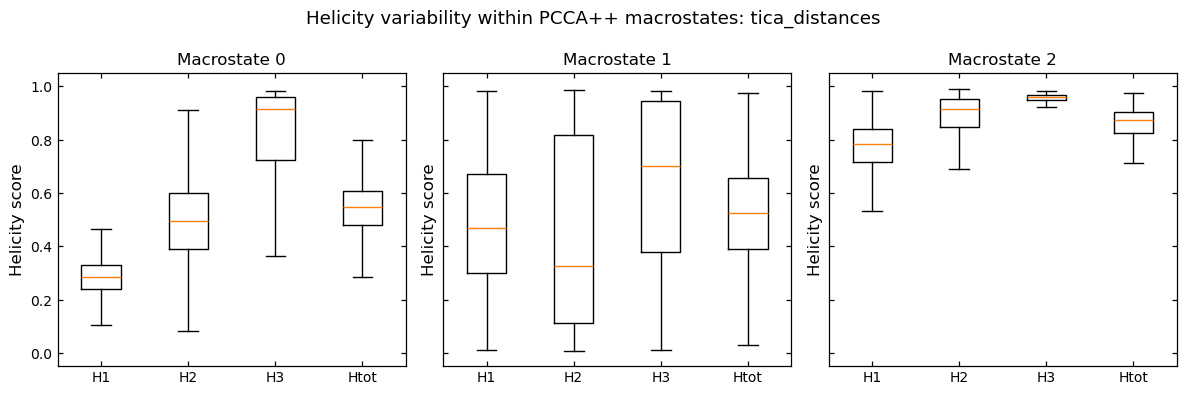

In [110]:
import matplotlib.pyplot as plt

for name in trajectories_labels:
    hard = hard_assignments_timeseries_dict[name]
    n_macrostates = pcca_memberships_dict[name].shape[1]

    observables = {
        "H1": helicity_timeseries["H1"],
        "H2": helicity_timeseries["H2"],
        "H3": helicity_timeseries["H3"],
        "Htot": helicity_timeseries["Htot"],
    }

    obs_names = list(observables.keys())

    fig, axs = plt.subplots(
        nrows=1,
        ncols=n_macrostates,
        figsize=(4 * n_macrostates, 4),
        sharey=True
    )

    if n_macrostates == 1:
        axs = [axs]

    for macro in range(n_macrostates):
        mask = hard == macro

        data = [
            observables[obs_name][mask]
            for obs_name in obs_names
        ]

        axs[macro].boxplot(
            data,
            labels=obs_names,
            showfliers=False
        )

        axs[macro].set_title(f"Macrostate {macro}")
        axs[macro].set_ylim(-0.05, 1.05)
        axs[macro].set_ylabel("Helicity score")

    fig.suptitle(f"Helicity variability within PCCA++ macrostates: {name}")
    plt.tight_layout()
    plt.show()

In [111]:
name = trajectories_labels[0]   # or choose explicitly, e.g. "tica_distances"
macro_to_inspect = 1            # choose 0, 1, or 2

In [112]:
dtraj = dtrajs_dict[name]
hard_macro = hard_assignments_timeseries_dict[name]

n_microstates = pcca_memberships_dict[name].shape[0]
n_macrostates = pcca_memberships_dict[name].shape[1]

print("Model:", name)
print("n microstates:", n_microstates)
print("n macrostates:", n_macrostates)
print("macrostate counts:", np.bincount(hard_macro))

Model: tica_distances
n microstates: 30
n macrostates: 3
macrostate counts: [  15883  475514 1034644]


In [113]:
memberships = pcca_memberships_dict[name]

micro_to_macro = np.argmax(memberships, axis=1)

microstates_in_macro = np.where(micro_to_macro == macro_to_inspect)[0]

print(f"Microstates in macrostate {macro_to_inspect}:")
print(microstates_in_macro)

Microstates in macrostate 1:
[ 1  2  3  4  5  7  8 10 11 13 14 15 16 17 18 19 20 21 23 24 26 28 29]


In [114]:
microstate_rows = []

observables = {
    "H1": helicity_timeseries["H1"],
    "H2": helicity_timeseries["H2"],
    "H3": helicity_timeseries["H3"],
    "Htot": helicity_timeseries["Htot"],
}

for micro in microstates_in_macro:
    mask = dtraj == micro

    row = {
        "model": name,
        "macrostate": macro_to_inspect,
        "microstate": micro,
        "n_frames": np.sum(mask),
        "fraction_frames_total": np.mean(mask),
        "pcca_membership": memberships[micro, macro_to_inspect],
    }

    for obs_name, obs in observables.items():
        values = obs[mask]

        row[f"{obs_name}_mean"] = np.nanmean(values)
        row[f"{obs_name}_std"] = np.nanstd(values)
        row[f"{obs_name}_median"] = np.nanmedian(values)
        row[f"{obs_name}_q25"] = np.nanpercentile(values, 25)
        row[f"{obs_name}_q75"] = np.nanpercentile(values, 75)

    microstate_rows.append(row)

microstate_helicity_df = pd.DataFrame(microstate_rows)

microstate_helicity_df = microstate_helicity_df.sort_values(
    by="fraction_frames_total",
    ascending=False
)

microstate_helicity_df

,model,macrostate,microstate,n_frames,fraction_frames_total,pcca_membership,H1_mean,H1_std,H1_median,H1_q25,...,H3_mean,H3_std,H3_median,H3_q25,H3_q75,Htot_mean,Htot_std,Htot_median,Htot_q25,Htot_q75
10,tica_distances,1,14,34024,0.022296,0.807044,0.550007,0.243759,0.561676,0.367934,...,0.828737,0.152661,0.897661,0.725025,0.958350,0.559901,0.134425,0.553369,0.470006,0.644292
17,tica_distances,1,21,33864,0.022191,0.762412,0.633042,0.225330,0.645784,0.487092,...,0.826760,0.153360,0.888935,0.722153,0.958347,0.657084,0.141721,0.655080,0.555301,0.763870
21,tica_distances,1,28,33735,0.022106,0.734895,0.602382,0.230307,0.614162,0.433868,...,0.846030,0.145245,0.917858,0.755199,0.960593,0.662458,0.138151,0.661234,0.563649,0.764133
3,tica_distances,1,4,29887,0.019585,0.783133,0.393808,0.193754,0.381632,0.263512,...,0.824011,0.156880,0.887124,0.724489,0.957089,0.549094,0.136002,0.538888,0.450186,0.646673
0,tica_distances,1,1,26636,0.017454,0.792227,0.522075,0.245133,0.523331,0.334078,...,0.828332,0.158359,0.900790,0.728089,0.959055,0.554274,0.142643,0.542533,0.454342,0.645853
4,tica_distances,1,5,26336,0.017258,0.583374,0.314448,0.136430,0.325715,0.220739,...,0.907956,0.112855,0.955906,0.918174,0.965955,0.691372,0.082278,0.707556,0.651469,0.748680
20,tica_distances,1,26,24669,0.016165,0.779807,0.333817,0.184455,0.344350,0.180278,...,0.819250,0.170899,0.898258,0.714318,0.959137,0.538396,0.142200,0.535777,0.436176,0.648178
12,tica_distances,1,16,24173,0.015840,0.801988,0.332904,0.195866,0.322402,0.168401,...,0.813848,0.168523,0.883300,0.706603,0.957374,0.479692,0.133322,0.466921,0.387925,0.560657
13,tica_distances,1,17,21618,0.014166,0.559032,0.452521,0.195607,0.454136,0.319883,...,0.875832,0.134152,0.947678,0.824716,0.964213,0.699038,0.115023,0.712487,0.635027,0.780289
5,tica_distances,1,7,20882,0.013684,0.911054,0.577209,0.233190,0.578360,0.399078,...,0.226450,0.106585,0.254536,0.129886,0.298059,0.377587,0.137902,0.363319,0.275646,0.467511


In [115]:
total_frames_in_macro_microstates = microstate_helicity_df["n_frames"].sum()

microstate_helicity_df["fraction_within_macrostate"] = (
    microstate_helicity_df["n_frames"] / total_frames_in_macro_microstates
)

microstate_helicity_df

,model,macrostate,microstate,n_frames,fraction_frames_total,pcca_membership,H1_mean,H1_std,H1_median,H1_q25,...,H3_std,H3_median,H3_q25,H3_q75,Htot_mean,Htot_std,Htot_median,Htot_q25,Htot_q75,fraction_within_macrostate
10,tica_distances,1,14,34024,0.022296,0.807044,0.550007,0.243759,0.561676,0.367934,...,0.152661,0.897661,0.725025,0.958350,0.559901,0.134425,0.553369,0.470006,0.644292,0.071552
17,tica_distances,1,21,33864,0.022191,0.762412,0.633042,0.225330,0.645784,0.487092,...,0.153360,0.888935,0.722153,0.958347,0.657084,0.141721,0.655080,0.555301,0.763870,0.071216
21,tica_distances,1,28,33735,0.022106,0.734895,0.602382,0.230307,0.614162,0.433868,...,0.145245,0.917858,0.755199,0.960593,0.662458,0.138151,0.661234,0.563649,0.764133,0.070944
3,tica_distances,1,4,29887,0.019585,0.783133,0.393808,0.193754,0.381632,0.263512,...,0.156880,0.887124,0.724489,0.957089,0.549094,0.136002,0.538888,0.450186,0.646673,0.062852
0,tica_distances,1,1,26636,0.017454,0.792227,0.522075,0.245133,0.523331,0.334078,...,0.158359,0.900790,0.728089,0.959055,0.554274,0.142643,0.542533,0.454342,0.645853,0.056015
4,tica_distances,1,5,26336,0.017258,0.583374,0.314448,0.136430,0.325715,0.220739,...,0.112855,0.955906,0.918174,0.965955,0.691372,0.082278,0.707556,0.651469,0.748680,0.055384
20,tica_distances,1,26,24669,0.016165,0.779807,0.333817,0.184455,0.344350,0.180278,...,0.170899,0.898258,0.714318,0.959137,0.538396,0.142200,0.535777,0.436176,0.648178,0.051879
12,tica_distances,1,16,24173,0.015840,0.801988,0.332904,0.195866,0.322402,0.168401,...,0.168523,0.883300,0.706603,0.957374,0.479692,0.133322,0.466921,0.387925,0.560657,0.050836
13,tica_distances,1,17,21618,0.014166,0.559032,0.452521,0.195607,0.454136,0.319883,...,0.134152,0.947678,0.824716,0.964213,0.699038,0.115023,0.712487,0.635027,0.780289,0.045462
5,tica_distances,1,7,20882,0.013684,0.911054,0.577209,0.233190,0.578360,0.399078,...,0.106585,0.254536,0.129886,0.298059,0.377587,0.137902,0.363319,0.275646,0.467511,0.043915


In [116]:
cols = [
    "model",
    "macrostate",
    "microstate",
    "n_frames",
    "fraction_within_macrostate",
    "pcca_membership",
    "H1_mean",
    "H2_mean",
    "H3_mean",
    "Htot_mean",
    "H1_std",
    "H2_std",
    "H3_std",
    "Htot_std",
]

microstate_helicity_summary = microstate_helicity_df[cols]

microstate_helicity_summary

,model,macrostate,microstate,n_frames,fraction_within_macrostate,pcca_membership,H1_mean,H2_mean,H3_mean,Htot_mean,H1_std,H2_std,H3_std,Htot_std
10,tica_distances,1,14,34024,0.071552,0.807044,0.550007,0.300957,0.828737,0.559901,0.243759,0.287724,0.152661,0.134425
17,tica_distances,1,21,33864,0.071216,0.762412,0.633042,0.511449,0.826760,0.657084,0.225330,0.324945,0.153360,0.141721
21,tica_distances,1,28,33735,0.070944,0.734895,0.602382,0.538964,0.846030,0.662458,0.230307,0.332890,0.145245,0.138151
3,tica_distances,1,4,29887,0.062852,0.783133,0.393808,0.429464,0.824011,0.549094,0.193754,0.324404,0.156880,0.136002
0,tica_distances,1,1,26636,0.056015,0.792227,0.522075,0.312415,0.828332,0.554274,0.245133,0.304307,0.158359,0.142643
4,tica_distances,1,5,26336,0.055384,0.583374,0.314448,0.851712,0.907956,0.691372,0.136430,0.159176,0.112855,0.082278
20,tica_distances,1,26,24669,0.051879,0.779807,0.333817,0.462120,0.819250,0.538396,0.184455,0.338207,0.170899,0.142200
12,tica_distances,1,16,24173,0.050836,0.801988,0.332904,0.292324,0.813848,0.479692,0.195866,0.294696,0.168523,0.133322
13,tica_distances,1,17,21618,0.045462,0.559032,0.452521,0.768761,0.875832,0.699038,0.195607,0.241313,0.134152,0.115023
5,tica_distances,1,7,20882,0.043915,0.911054,0.577209,0.329100,0.226450,0.377587,0.233190,0.307172,0.106585,0.137902


In [119]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Choose model and macrostate
# -----------------------------

name = trajectories_labels[0]   # or e.g. "tica_distances"
macro_to_inspect = 1            # choose 0, 1, or 2

dtraj = dtrajs_dict[name]
memberships = pcca_memberships_dict[name]

# microstate -> most likely macrostate
micro_to_macro = np.argmax(memberships, axis=1)

# microstates belonging to selected macrostate
microstates_in_macro = np.where(micro_to_macro == macro_to_inspect)[0]

# sort them by population within the trajectory
microstate_counts = np.array([
    np.sum(dtraj == micro)
    for micro in microstates_in_macro
])

order = np.argsort(microstate_counts)[::-1]
microstates_in_macro = microstates_in_macro[order]
microstate_counts = microstate_counts[order]

print("Microstates in macrostate:", microstates_in_macro)
print("Counts:", microstate_counts)
print("PCCA memberships:", memberships[microstates_in_macro, macro_to_inspect])

Microstates in macrostate: [14 21 28  4  1  5 26 16 17  7 13 20 19 10  3  2 15 23  8 24 11 18 29]
Counts: [34024 33864 33735 29887 26636 26336 24669 24173 21618 20882 20868 20842
 18258 17485 16842 16393 15227 14929 12815 12779 12462 11835  8955]
PCCA memberships: [0.80704368 0.76241222 0.73489498 0.78313262 0.79222748 0.58337428
 0.77980724 0.80198761 0.55903205 0.91105403 1.         0.8345389
 0.9440418  0.85050834 0.95480645 0.92024276 0.89735393 0.80924804
 0.56007331 0.87929079 0.89269536 0.95235731 0.93291326]


/var/folders/vk/kftm8379123bsmwrdp8l0xr00000gn/T/ipykernel_3017/4179187652.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/var/folders/vk/kftm8379123bsmwrdp8l0xr00000gn/T/ipykernel_3017/4179187652.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/var/folders/vk/kftm8379123bsmwrdp8l0xr00000gn/T/ipykernel_3017/4179187652.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


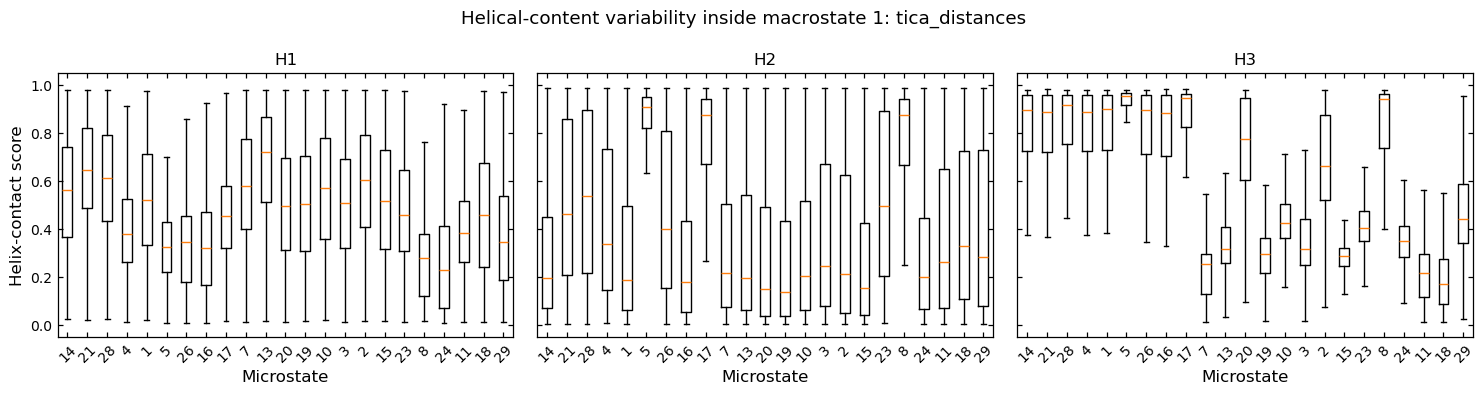

In [120]:
# -----------------------------
# Boxplot of helicity by microstate
# -----------------------------

observables = {
    "H1": helicity_timeseries["H1"],
    "H2": helicity_timeseries["H2"],
    "H3": helicity_timeseries["H3"],
}

fig, axs = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(15, 4),
    sharey=True
)

for ax, (obs_name, obs) in zip(axs, observables.items()):
    data = []
    labels = []

    for micro in microstates_in_macro:
        mask = dtraj == micro
        values = obs[mask]

        # skip empty or nearly empty microstates
        if len(values) < 5:
            continue

        data.append(values)
        labels.append(str(micro))

    ax.boxplot(
        data,
        labels=labels,
        showfliers=False
    )

    ax.set_title(obs_name)
    ax.set_xlabel("Microstate")
    ax.set_ylim(-0.05, 1.05)
    ax.tick_params(axis="x", rotation=45)

axs[0].set_ylabel("Helix-contact score")

fig.suptitle(
    f"Helical-content variability inside macrostate {macro_to_inspect}: {name}"
)

plt.tight_layout()
plt.show()

In [122]:
# Sort microstates by decreasing population
order = np.argsort(plot_fractions)[::-1]

plot_microstates = [plot_microstates[i] for i in order]
plot_counts = [plot_counts[i] for i in order]
plot_fractions = plot_fractions[order]
plot_widths = plot_widths[order]

NameError: name 'plot_fractions' is not defined

/var/folders/vk/kftm8379123bsmwrdp8l0xr00000gn/T/ipykernel_3017/3444164614.py:70: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/var/folders/vk/kftm8379123bsmwrdp8l0xr00000gn/T/ipykernel_3017/3444164614.py:70: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/var/folders/vk/kftm8379123bsmwrdp8l0xr00000gn/T/ipykernel_3017/3444164614.py:70: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


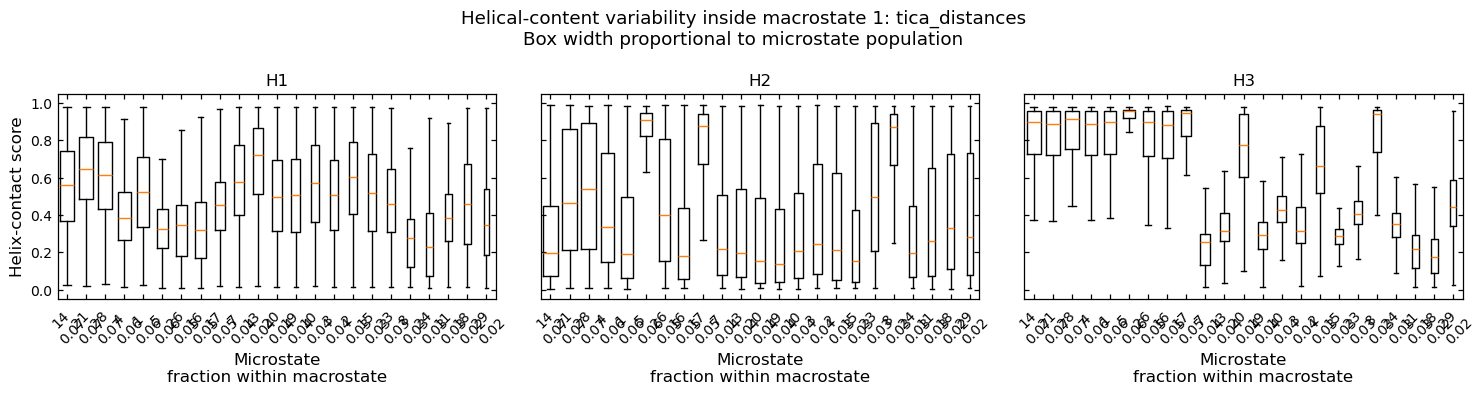

In [123]:
# -----------------------------
# Boxplot of helicity by microstate
# Box width = population within macrostate
# -----------------------------

observables = {
    "H1": helicity_timeseries["H1"],
    "H2": helicity_timeseries["H2"],
    "H3": helicity_timeseries["H3"],
}

fig, axs = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(15, 4),
    sharey=True
)

# Total population of the selected microstates
total_macro_frames = np.sum([
    np.sum(dtraj == micro)
    for micro in microstates_in_macro
])

# Build common labels and widths once, so all panels are aligned
plot_microstates = []
plot_counts = []
plot_fractions = []
plot_widths = []

min_frames = 5

for micro in microstates_in_macro:
    count = np.sum(dtraj == micro)

    if count < min_frames:
        continue

    frac = count / total_macro_frames

    plot_microstates.append(micro)
    plot_counts.append(count)
    plot_fractions.append(frac)

plot_fractions = np.array(plot_fractions)

# Rescale widths to a readable range
# largest microstate gets max_width, smaller ones scale proportionally
max_width = 0.75
min_width = 0.15

plot_widths = min_width + (
    (plot_fractions / plot_fractions.max()) * (max_width - min_width)
)

for ax, (obs_name, obs) in zip(axs, observables.items()):
    data = []
    labels = []

    for micro, frac in zip(plot_microstates, plot_fractions):
        mask = dtraj == micro
        values = obs[mask]

        data.append(values)
        labels.append(
            f"{micro}\n"
            f"{frac:.2f}"
        )

    ax.boxplot(
        data,
        labels=labels,
        widths=plot_widths,
        showfliers=False
    )

    ax.set_title(obs_name)
    ax.set_xlabel("Microstate\nfraction within macrostate")
    ax.set_ylim(-0.05, 1.05)
    ax.tick_params(axis="x", rotation=45)

axs[0].set_ylabel("Helix-contact score")

fig.suptitle(
    f"Helical-content variability inside macrostate {macro_to_inspect}: {name}\n"
    "Box width proportional to microstate population"
)

plt.tight_layout()
plt.show()